# FD-A - training set

Exploration only. TF-C's own preprocessed FD-A: the unlabelled pretraining set of Part F.

Read through `eda/tfc_data.py` from the files inside the unchanged TF-C checkout, so this sees exactly the tensors TF-C consumes. Figures use the training split; the test split is only counted, never plotted.

In [1]:
import sys
from pathlib import Path

ROOT = next(d for d in [Path.cwd(), *Path.cwd().parents] if (d / "src" / "config.yaml").exists())
for p in (str(ROOT), str(ROOT / "eda")):
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np

from plots import plot_class_examples, plot_class_spectra
from src.utils.config import load_config
from tfc_data import CLASS_NAMES, SAMPLING_HZ, SPLITS, class_counts, load_split

DATASET, KEY = "FD-A", "fd_a"
cfg = load_config()
print(cfg["tfc_data"][KEY])

C:/Users/Bruger/Documents/Repos/Time series research/TFC-pretraining/datasets/FD-A


## Load

In [2]:
X_train, y_train = load_split(cfg, KEY, "train")
X_train.shape, y_train.shape

((8184, 1, 5120), (8184,))

## Shape

In [3]:
n_series, n_channels, n_timestamps = X_train.shape

print(f"series      {n_series}")
print(f"channels    {n_channels}")
print(f"timestamps  {n_timestamps}  ({n_timestamps / SAMPLING_HZ * 1000:.0f} ms at {SAMPLING_HZ / 1000:.0f} kHz)")

classes, counts = np.unique(y_train, return_counts=True)
print()
print(f"classes     {len(classes)}")
for cls, count in zip(classes, counts):
    print(f"  {CLASS_NAMES[cls]:<12} {count:5d}  ({count / n_series:.1%})")

print()
print(f"missing     {int(np.isnan(X_train).sum())}")

series      8184
channels    1
timestamps  5120  (80 ms at 64 kHz)

classes     3
  class 0        744  (9.1%)
  class 1       3720  (45.5%)
  class 2       3720  (45.5%)

missing     0


## Splits and class balance

Labels only. `majority` is the accuracy of always predicting the largest class - the floor any reported accuracy has to clear, and the reason macro-F1 is worth reading next to it.

In [4]:
counts = class_counts(cfg, KEY)
print(f"{'split':<6} {'n':>6}   " + "  ".join(f"{name:>8}" for name in CLASS_NAMES) + "   majority")
for split in SPLITS:
    c = counts[split]
    print(f"{split:<6} {c.sum():>6}   " + "  ".join(f"{v:>8}" for v in c) + f"   {c.max() / c.sum():.1%}")

split       n    class 0   class 1   class 2   majority
train    8184        744      3720      3720   45.5%
val      2728        248      1240      1240   45.5%
test     2728        248      1240      1240   45.5%


## Scale

Per-series mean and standard deviation, by class. The files are not z-normalised, so amplitude itself may separate classes; TF-C applies no scaler of its own before the encoder.

In [5]:
per_series_mean = X_train.mean(axis=(1, 2))
per_series_sd = X_train.std(axis=(1, 2))

print(f"overall     mean {X_train.mean():+.4f}   sd {X_train.std():.4f}   "
      f"min {X_train.min():+.3f}   max {X_train.max():+.3f}")
print()
print(f"{'':<12} {'n':>5}   {'series mean':>20}   {'series sd':>20}")
for cls in classes:
    m, s = per_series_mean[y_train == cls], per_series_sd[y_train == cls]
    print(f"{CLASS_NAMES[cls]:<12} {len(m):>5}   {m.mean():+.4f} +/- {m.std():.4f}"
          f"   {s.mean():.4f} +/- {s.std():.4f}")

overall     mean +0.0318   sd 0.1957   min -5.304   max +5.008

                 n            series mean              series sd
class 0        744   -0.0150 +/- 0.0052   0.3628 +/- 0.0229
class 1       3720   +0.0316 +/- 0.0213   0.1796 +/- 0.0707
class 2       3720   +0.0414 +/- 0.0022   0.1378 +/- 0.0233


## One series per class

Small multiples on shared axes, so panels are directly comparable. The example index is drawn with a fixed seed.

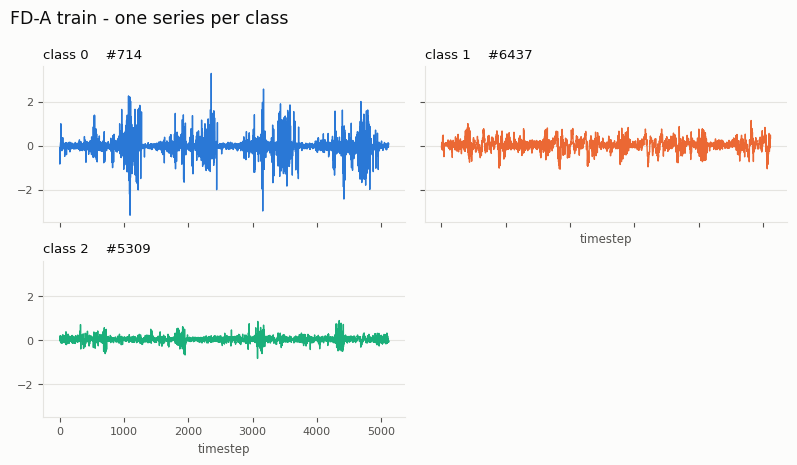

In [6]:
fig = plot_class_examples(X_train, y_train, CLASS_NAMES, f"{DATASET} train - one series per class")

## Zoom

5120 steps drawn in a few hundred pixels show only the envelope. The first 512 steps of the same series show the waveform.

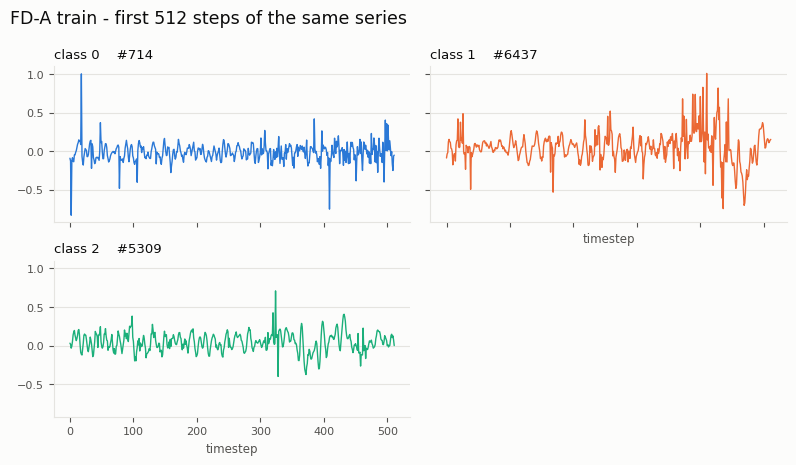

In [7]:
ZOOM = 512   # 8 ms
fig = plot_class_examples(X_train[:, :, :ZOOM], y_train, CLASS_NAMES,
                          f"{DATASET} train - first {ZOOM} steps of the same series")

## Spectrum

Mean amplitude spectrum per class (each series' own mean removed, log scale). TF-C's frequency branch takes `abs(fft(x))` of exactly these windows, so this is the view that branch is given.

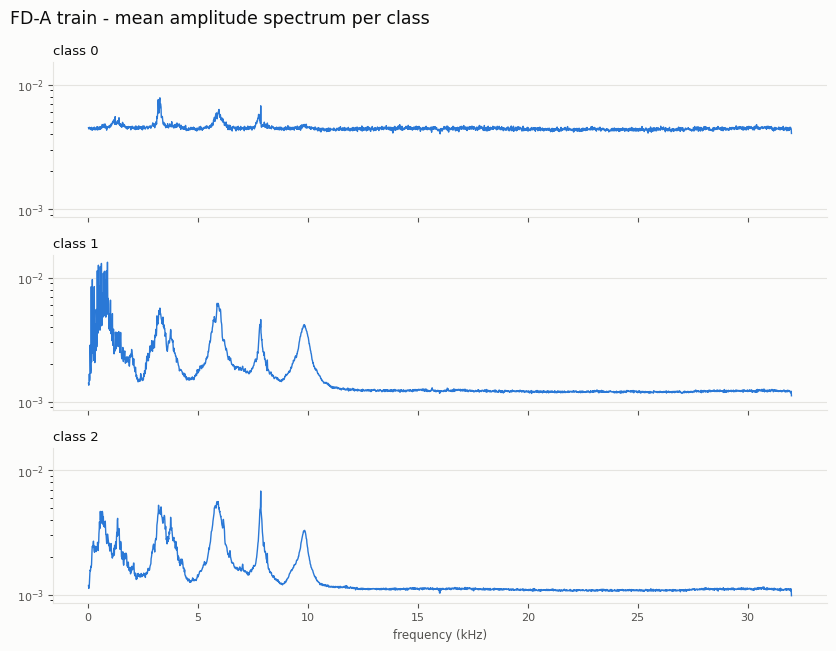

In [8]:
fig = plot_class_spectra({DATASET: (X_train, y_train)}, CLASS_NAMES, SAMPLING_HZ,
                         f"{DATASET} train - mean amplitude spectrum per class")